In [1]:
import pandas as pd
import numpy as np

# Load the customer-level cleaned data
df_customers = pd.read_csv('data/processed/sales_with_customers.csv', parse_dates=['InvoiceDate'])
print(f"Loaded {len(df_customers):,} rows, {df_customers['Customer ID'].nunique():,} unique customers")

Loaded 805,549 rows, 5,878 unique customers


In [2]:
# ============================================
# RFM FEATURE ENGINEERING
# ============================================

reference_date = df_customers['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

rfm = df_customers.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
print(rfm.head(10))
print("\n--- RFM Statistics ---")
print(rfm.describe())

Reference date: 2011-12-10 12:50:00

RFM table shape: (5878, 4)
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61

--- RFM Statistics ---
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     8

In [3]:
print("--- Top 10 by Monetary ---")
print(rfm.nlargest(10, 'Monetary'))

print("\n--- Top 10 by Frequency ---")
print(rfm.nlargest(10, 'Frequency'))

--- Top 10 by Monetary ---
      Customer ID  Recency  Frequency   Monetary
5692        18102        1        145  608821.65
2277        14646        2        151  528602.52
1789        14156       10        156  313946.37
2538        14911        1        398  295972.63
5050        17450        8         51  246973.09
1331        13694        4        143  196482.81
5109        17511        3         60  175603.55
4061        16446        1          2  168472.50
4295        16684        4         55  147142.77
68          12415       24         28  144458.37

--- Top 10 by Frequency ---
      Customer ID  Recency  Frequency   Monetary
2538        14911        1        398  295972.63
400         12748        1        336   56599.39
5433        17841        2        211   70884.07
2935        15311        1        208  116771.16
739         13089        3        203  116737.86
2237        14606        1        192   30861.06
1789        14156       10        156  313946.37
5442        1

In [4]:
# ============================================
# HANDLE SKEWNESS: LOG TRANSFORM
# ============================================

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

print("--- Before vs After (skewness) ---")
print("Recency skew:", rfm['Recency'].skew(), "→", rfm['Recency_log'].skew())
print("Frequency skew:", rfm['Frequency'].skew(), "→", rfm['Frequency_log'].skew())
print("Monetary skew:", rfm['Monetary'].skew(), "→", rfm['Monetary_log'].skew())

print("\n--- Log-transformed stats ---")
print(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']].describe())

--- Before vs After (skewness) ---
Recency skew: 0.8871981571467127 → -0.48863086840642944
Frequency skew: 12.639950874973305 → 1.0014708931277454
Monetary skew: 25.31423531032663 → 0.2651126544218956

--- Log-transformed stats ---
       Recency_log  Frequency_log  Monetary_log
count  5878.000000    5878.000000   5878.000000
mean      4.454132       1.549588      6.836550
std       1.559404       0.809447      1.387864
min       0.693147       0.693147      1.373716
25%       3.295837       0.693147      5.857254
50%       4.574711       1.386294      6.802300
75%       5.942799       2.079442      7.744175
max       6.606650       5.988961     13.319282


Scaled features shape: (5878, 3)
Mean (should be ~0): [-0.  0. -0.]
Std (should be ~1): [1. 1. 1.]


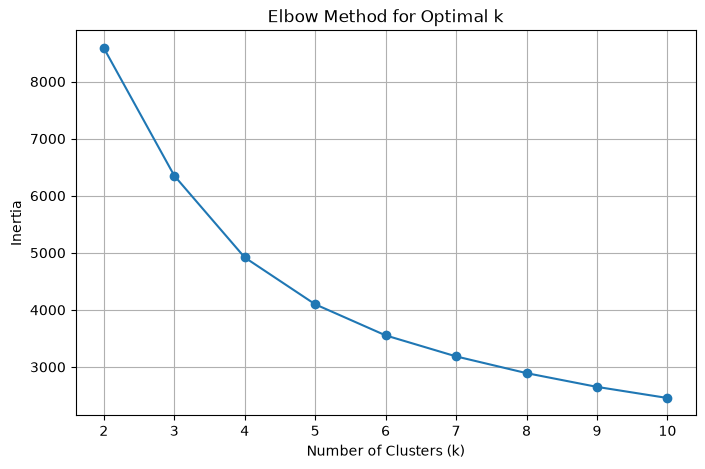


Inertia values: [8588.8, 6352.0, 4918.6, 4097.8, 3553.0, 3184.8, 2891.6, 2650.6, 2455.9]


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ============================================
# SCALE FEATURES
# ============================================

features = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Scaled features shape:", features_scaled.shape)
print("Mean (should be ~0):", features_scaled.mean(axis=0).round(3))
print("Std (should be ~1):", features_scaled.std(axis=0).round(3))

# ============================================
# ELBOW METHOD - find optimal k
# ============================================

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.savefig('docs/elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nInertia values:", [round(i, 1) for i in inertias])

In [7]:
Suggested elbow point: k = 3
Silhouette scores by k:
  k=2: 0.4381
  k=3: 0.3478
  k=4: 0.3653
  k=5: 0.3421
  k=6: 0.3336
  k=7: 0.3052
  k=8: 0.2970
  k=9: 0.2913
  k=10: 0.2918

Best k by silhouette score: 2

SyntaxError: invalid syntax (3581933891.py, line 1)

In [8]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    sil_scores.append(silhouette_score(features_scaled, labels))

print("Silhouette scores by k:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

best_k_silhouette = k_range[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k_silhouette}")

Silhouette scores by k:
  k=2: 0.4381
  k=3: 0.3478
  k=4: 0.3653
  k=5: 0.3421
  k=6: 0.3336
  k=7: 0.3052
  k=8: 0.2970
  k=9: 0.2913
  k=10: 0.2918

Best k by silhouette score: 2


In [9]:
# ============================================
# FINAL CLUSTERING: k=6
# ============================================

final_k = 6
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm['Segment'] = kmeans_final.fit_predict(features_scaled)

print(f"Cluster sizes:\n{rfm['Segment'].value_counts().sort_index()}")

# Business interpretation - average RFM per segment (using ORIGINAL, non-log values for readability)
segment_summary = rfm.groupby('Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('Customer ID', 'count')
).round(1)

print("\n--- Segment Profiles ---")
print(segment_summary)

Cluster sizes:
Segment
0     980
1     932
2    1476
3     725
4    1317
5     448
Name: count, dtype: int64

--- Segment Profiles ---
         Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Segment                                                 
0               40.9            2.0         538.7    980
1               90.8            9.8        4351.8    932
2              437.2            1.2         252.4   1476
3               13.0            6.5        2120.1    725
4              301.9            3.4        1233.0   1317
5               14.3           33.1       21487.0    448


Segment_Label
Lost/Churned       1476
At Risk            1317
New/Occasional      980
Big Spenders        932
Loyal Customers     725
Champions           448
Name: count, dtype: int64


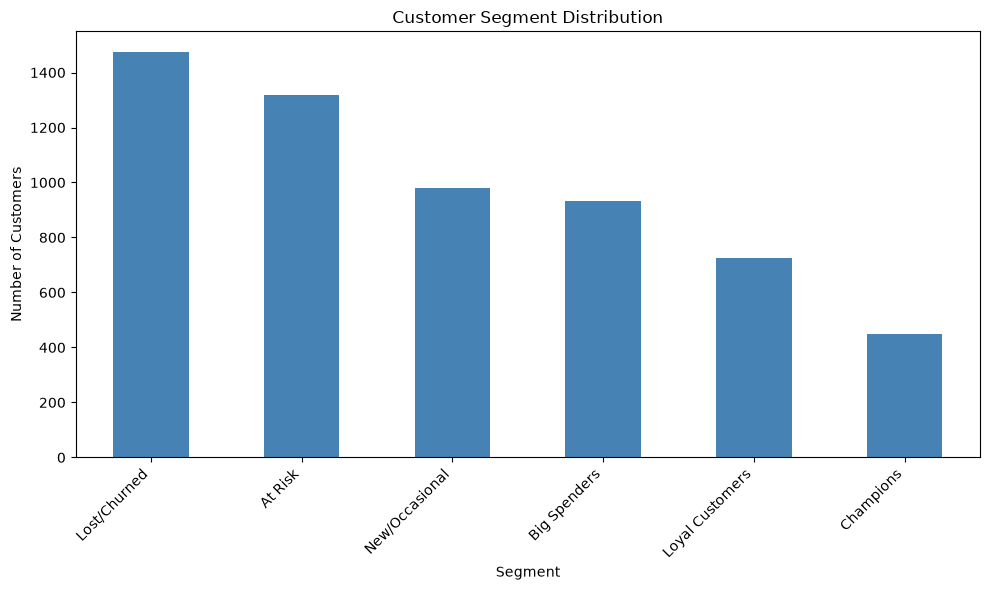


✅ Saved customer_segments.csv


In [10]:
segment_labels = {
    5: 'Champions',
    3: 'Loyal Customers',
    1: 'Big Spenders',
    0: 'New/Occasional',
    4: 'At Risk',
    2: 'Lost/Churned'
}

rfm['Segment_Label'] = rfm['Segment'].map(segment_labels)

print(rfm['Segment_Label'].value_counts())

# Visualize segment sizes
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
rfm['Segment_Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('docs/segment_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# Save the RFM + segment table for later use (dashboard, churn model)
rfm.to_csv('data/processed/customer_segments.csv', index=False)
print("\n✅ Saved customer_segments.csv")

In [11]:
total_revenue = rfm['Monetary'].sum()
champions_revenue = rfm[rfm['Segment_Label'] == 'Champions']['Monetary'].sum()
pct = (champions_revenue / total_revenue * 100)
print(f"Champions represent {448/5878*100:.1f}% of customers but {pct:.1f}% of total revenue")

Champions represent 7.6% of customers but 54.3% of total revenue
